# Etude 2 - CIFAR-10
## Classement d'images en 10 catégories à l'aide de réseaux de neurones (MLP et CNN).

#### Mise en place d'un bon environnement et architecture de notre dossier et création de fonction pour l'analyse de la base de données

In [1]:
# Imports et fonctions utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras import layers
from pathlib import Path
from keras import layers
import os, pickle

MODEL_FOLDER ="../models"
RESULT_FOLDER ="../results"
Path(MODEL_FOLDER).mkdir(parents=True, exist_ok=True)
Path(RESULT_FOLDER).mkdir(parents=True, exist_ok=True)

def show_data_img(X, n=200, shape=(28,28), dpi=100):
    plt.figure(figsize=(7.195, 3.841), dpi=dpi)
    nl = n // 20
    if n%20!=0: nl += 1
    
    for i in range(n):
        plt.subplot(nl,20,i+1)
        plt.imshow(X[i,:].reshape(shape), cmap='gray')
        plt.axis('off')
    plt.plot()

def show_model_errors_rgb(model, X, y, shape=(32,32,3)):
    proba = model.predict(X)
    y_pred = proba.argmax(axis=1)
    errors = [i for i in range(len(y_pred)) if y_pred[i]!=y[i]]
    
    # Affichage manuel pour RGB
    X_err, y_pred_err, y_true_err = X[errors], y_pred[errors], y[errors]
    n = min(len(X_err), 30)
    
    plt.figure(figsize=(7.195, 3.841), dpi=100)
    nl = n // 10
    if n % 10 != 0: nl += 1
    
    for i in range(n):
        plt.subplot(nl, 10, i+1)
        plt.imshow(X_err[i])
        plt.axis('off')
        plt.title(str(y_pred_err[i]) + ' (' + str(y_true_err[i]) + ')', fontsize=8)
    
    plt.tight_layout()
    plt.show()   

#### Chargement de la fonction qui permettra une meilleur lecture des graphiques

In [2]:
def plot_metrics(accuracy, loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in accuracy.keys()
    ))
    
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    for key, values in accuracy.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax1.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax1.set_title("Evolution de l'accuracy au cours de l'entrainement")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for key, values in loss.items():
        is_train = '_train' in key
        model = key.replace('_train', '').replace('_test', '')
        ax2.plot(values,
                 label=key,
                 color=color_map[model],
                 linewidth=2 if is_train else 1.2,
                 linestyle='-' if is_train else '--')
    ax2.set_title("Evolution de la loss au cours de l'entrainement")
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_loss(loss):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in loss.keys()
    ))
    
    # Même palette que plot_metrics pour garder les couleurs cohérentes
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for key, values in loss.items():
        if '_test' in key:
            model = key.replace('_test', '')
            ax.plot(values,
                    label=key,
                    color=color_map[model],
                    linewidth=1.2,
                    linestyle='-')
    
    ax.set_title("Evolution de la loss au cours de l'entrainement")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_mae(mae):
    models = list(dict.fromkeys(
        k.replace('_train', '').replace('_test', '') 
        for k in mae.keys()
    ))
    
    # Même palette que plot_metrics pour garder les couleurs cohérentes
    palette = plt.cm.tab10.colors
    color_map = {model: palette[i % len(palette)] for i, model in enumerate(models)}
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for key, values in mae.items():
        if '_test' in key:
            model = key.replace('_test', '')
            ax.plot(values,
                    label=key,
                    color=color_map[model],
                    linewidth=1.2,
                    linestyle='-')
    
    ax.set_title("Evolution de l'erreur absolue moyenne au cours de l'entrainement")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## 1. Exploration des données

In [3]:
# Séparations des données en 80/20 pour l'entraînement et le test
from keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

c:\#Document\Travail\BUT 3 S2\Winequality-CIFAR10-ML-Project\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


#### Affichage de la forme des données 


In [4]:
print("Forme X_train :", X_train.shape)
print("Forme y_train :", y_train.shape)
print("Forme X_test  :", X_test.shape)
print("Forme y_test  :", y_test.shape)

Forme X_train : (50000, 32, 32, 3)
Forme y_train : (50000, 1)
Forme X_test  : (10000, 32, 32, 3)
Forme y_test  : (10000, 1)


#### Affichage des 10 premières étiquettes de y_train et des valeurs uniques


In [5]:
print(y_train[:10])
print("Valeurs uniques :", np.unique(y_train))

[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]
Valeurs uniques : [0 1 2 3 4 5 6 7 8 9]


#### Ici on constate qu'on a 10 valeurs uniques y_train, ce qui correspond aux 10 classes d'images présentes dans le dataset CIFAR-10. En regardant la documentation de CIFAR-10 ces valeurs correspondent à : 

In [6]:
classes = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 
           'chien', 'grenouille', 'cheval', 'bateau', 'camion']

#### Nombre d'occurences de chaque classe dans y_train


In [7]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

#### Affichage de l'occurence de chaque classe dans y_train


<BarContainer object of 10 artists>

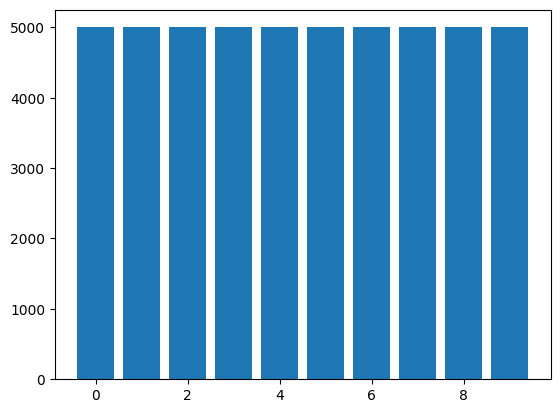

In [8]:
plt.bar(np.unique(y_train), np.unique(y_train, return_counts=True)[1])

#### Affichage des premmières valeurs de X_train


In [9]:
print("1ère donnée de X_train :", X_train[0])

1ère donnée de X_train : [[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


#### Affichage de 10 images de chaque classe


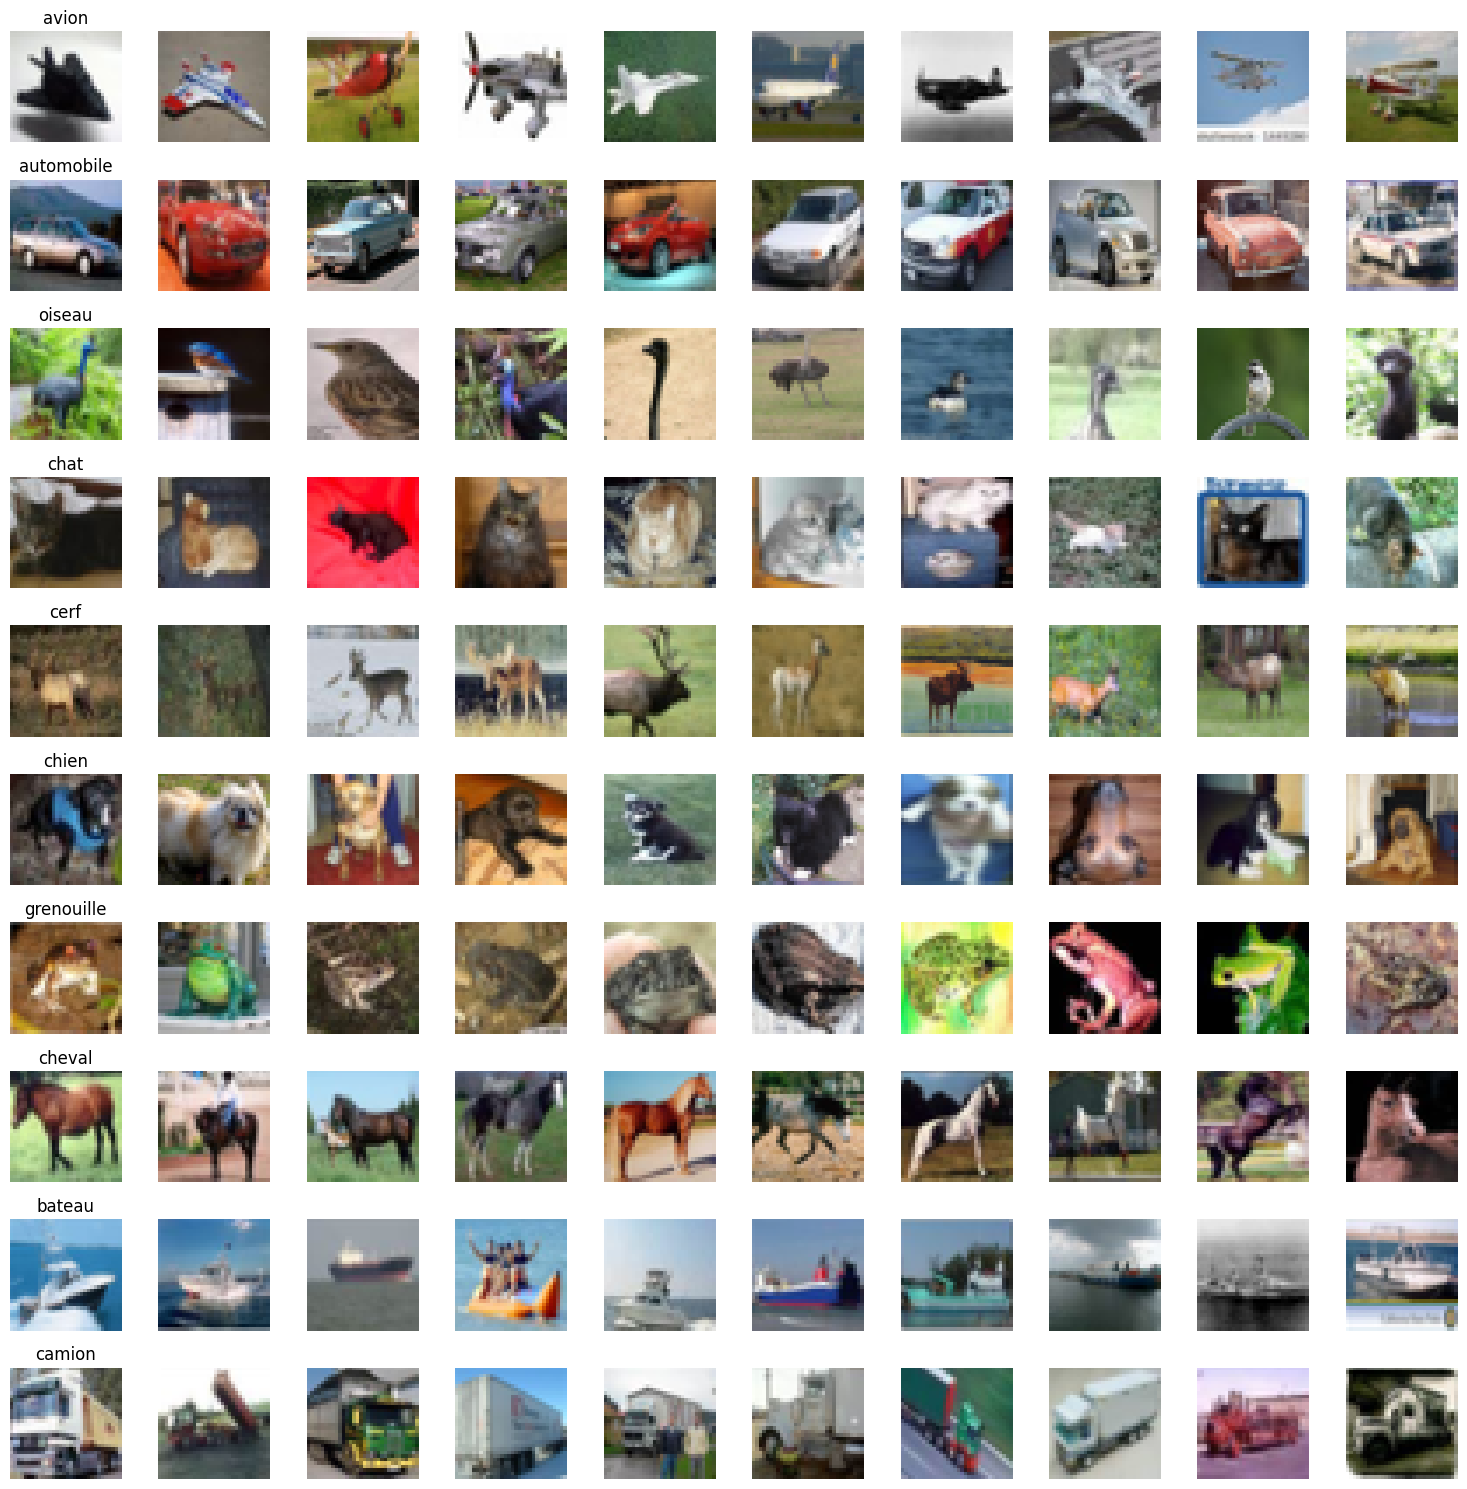

In [10]:
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for classe in range(10):
    indices = np.where(y_train == classe)[0][:10]
    for j in range(10):
        axes[classe][j].imshow(X_train[indices[j]])
        axes[classe][j].axis('off')
        if j == 0:
            axes[classe][0].set_title(classes[classe])

plt.tight_layout()
plt.show()

## 2. Préparation des données

#### Normalisation des données 

In [11]:
X_train = X_train / 255
X_test = X_test / 255
print("Min :", X_train.min(), "Max :", X_train.max())

Min : 0.0 Max : 1.0


#### Reshape pour rendre compatibles les entrées avec les modèles de Keras


In [12]:
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(y_train.shape)

(50000,)


#### Création des dictionnaire de stockage de nos résultats

In [13]:
accuracy = {}
loss = {}

#### Définition des fonction qui sont les différents modèles que nous allons anaylser

In [15]:
def baseline():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32, 32, 3)))
    m.add(keras.layers.Flatten()) # Très utile car on est sur des données sur 3 cannals (le RGB)
    m.add(keras.layers.Dense(32, activation = 'relu'))
    m.add(keras.layers.Dense(10, activation= 'softmax'))

    m.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m, "baseline"

def avance_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_33"


def avance_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance_55"


def avance_augmentation_55():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(5,5), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance55_V4"


def avance_augmentation_33():
    m = keras.models.Sequential()
    m.add(keras.layers.Input(shape=(32,32,3)))
    
    m.add(layers.RandomFlip("horizontal"))
    m.add(layers.RandomRotation(0.05))

    
    m.add(layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))
    m.add(layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
    m.add(layers.MaxPooling2D(pool_size=(2,2)))

    m.add(keras.layers.Flatten())
    m.add(keras.layers.Dense(10, activation='softmax'))

    m.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
    return m, "avance33_V5"


In [16]:
%%capture
models = [baseline,avance_33,avance_55,avance_augmentation_33,avance_augmentation_55]
taille_batch = 64
nb_epochs = 100

for model_func in models:
    model, nom = model_func()
    print(f"\n=== Entrainement de {nom} ===")
    model.summary()
    
    s = model.fit(X_train, y_train, batch_size=taille_batch, epochs=nb_epochs, verbose=1, validation_data=(X_test, y_test),callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)])
    
    accuracy[nom+"_train"] = s.history['accuracy']
    accuracy[nom+"_test"] = s.history['val_accuracy']
    
    loss[nom+"_train"] = s.history['loss']
    loss[nom+"_test"] = s.history['val_loss']
    
    model.save(MODEL_FOLDER+"/CIFAR_"+nom+".keras")
    print(f"{nom} sauvegardé")

    with open(RESULT_FOLDER+"/CIFAR_accuracy_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['accuracy'], "val": s.history['val_accuracy']}, f)
    
    with open(RESULT_FOLDER+"/CIFAR_loss_"+nom+".pickle", "wb") as f:
        pickle.dump({"train": s.history['loss'], "val": s.history['val_loss']}, f)

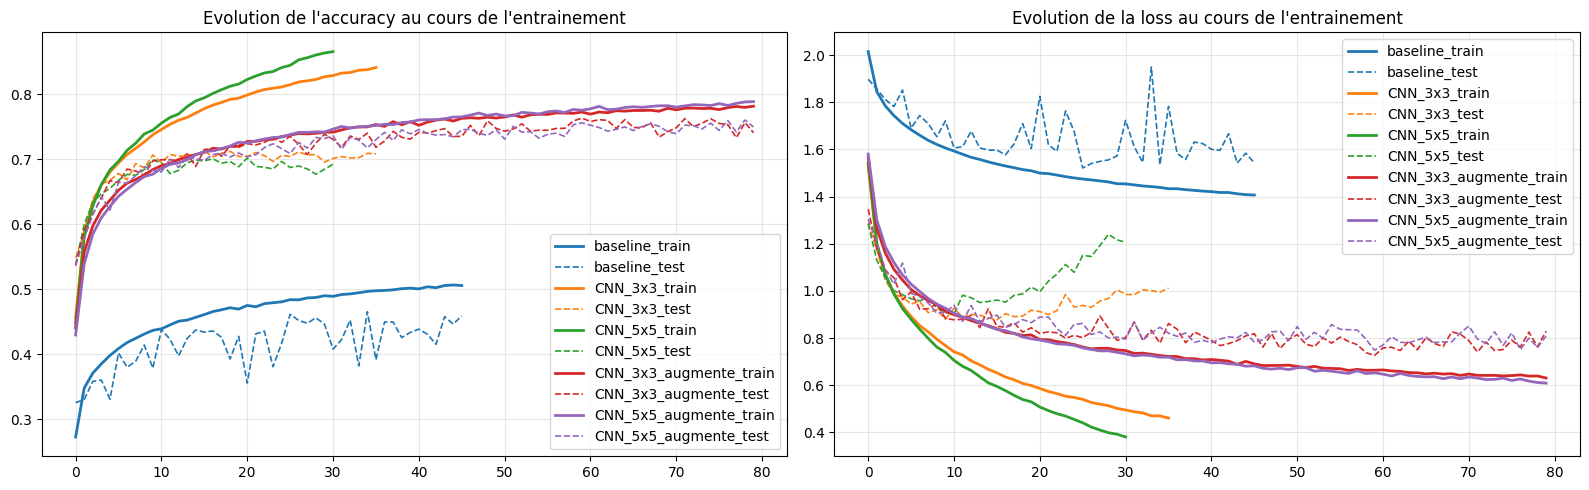

In [27]:
plot_metrics(accuracy, loss)

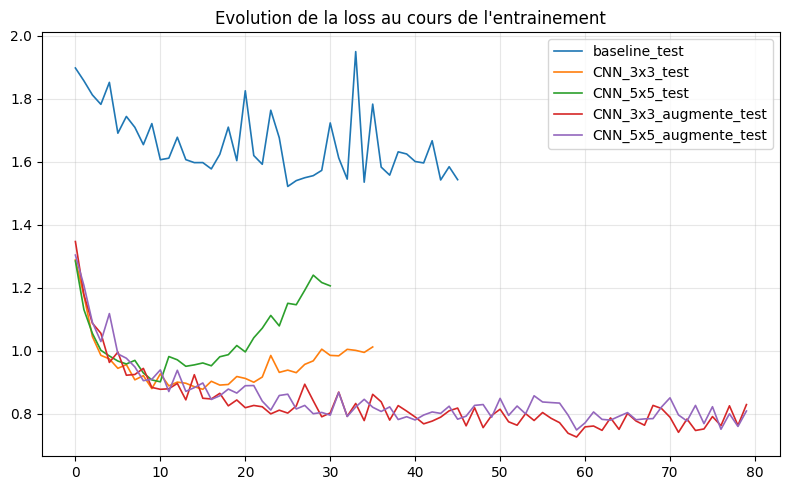

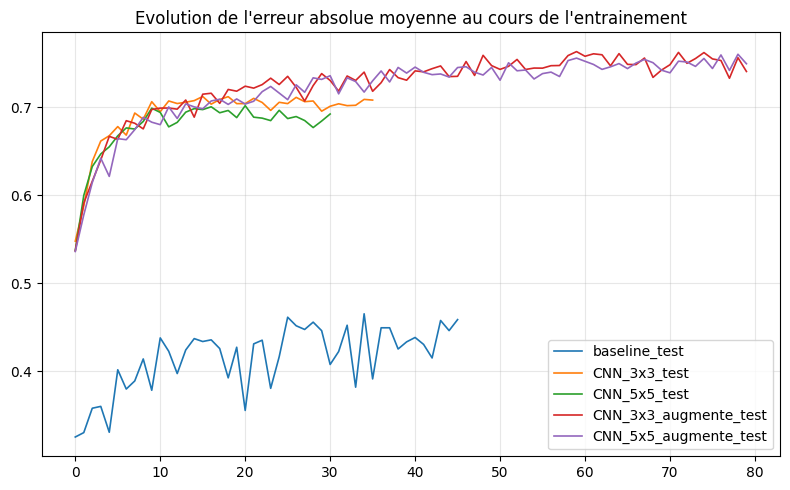

In [28]:
plot_loss(loss)
plot_mae(accuracy)

# Si besoin de recharger des modèles

In [18]:
from keras.models import load_model

# Recharger les résultats pickle
accuracy = {}
loss = {}

models_noms = ['baseline', 'avance_33', 'avance_55', 'avance33_V5', 'avance55_V4']

for nom in models_noms:
    acc_path = RESULT_FOLDER + f"/CIFAR_accuracy_{nom}.pickle"
    loss_path = RESULT_FOLDER + f"/CIFAR_loss_{nom}.pickle"
    if os.path.exists(acc_path):
        with open(acc_path, "rb") as f:
            data = pickle.load(f)
            accuracy[nom+"_train"] = data["train"]
            accuracy[nom+"_test"] = data["val"]
        print(f"{nom} accuracy chargé ✓")
    else:
        print(f"⚠️ {nom} accuracy introuvable")
    
    if os.path.exists(loss_path):
        with open(loss_path, "rb") as f:
            data = pickle.load(f)
            loss[nom+"_train"] = data["train"]
            loss[nom+"_test"] = data["val"]
        print(f"{nom} loss chargé ✓")
    else:
        print(f"⚠️ {nom} loss introuvable")

# Mapping ancien nom → nouveau nom
rename_map = {
    'baseline'  : 'baseline',
    'avance_33' : 'CNN_3x3',
    'avance_55' : 'CNN_5x5',
    'avance33_V5': 'CNN_3x3_augmente',
    'avance55_V4': 'CNN_5x5_augmente'
}

# Renommer les clés dans accuracy et loss
accuracy = {k.replace(ancien, nouveau): v 
            for ancien, nouveau in rename_map.items() 
            for k, v in accuracy.items() 
            if ancien in k}

loss = {k.replace(ancien, nouveau): v 
        for ancien, nouveau in rename_map.items() 
        for k, v in loss.items() 
        if ancien in k}

print("Clés accuracy :", list(accuracy.keys()))
print("Clés loss     :", list(loss.keys()))

baseline accuracy chargé ✓
baseline loss chargé ✓
avance_33 accuracy chargé ✓
avance_33 loss chargé ✓
avance_55 accuracy chargé ✓
avance_55 loss chargé ✓
avance33_V5 accuracy chargé ✓
avance33_V5 loss chargé ✓
avance55_V4 accuracy chargé ✓
avance55_V4 loss chargé ✓
Clés accuracy : ['baseline_train', 'baseline_test', 'CNN_3x3_train', 'CNN_3x3_test', 'CNN_5x5_train', 'CNN_5x5_test', 'CNN_3x3_augmente_train', 'CNN_3x3_augmente_test', 'CNN_5x5_augmente_train', 'CNN_5x5_augmente_test']
Clés loss     : ['baseline_train', 'baseline_test', 'CNN_3x3_train', 'CNN_3x3_test', 'CNN_5x5_train', 'CNN_5x5_test', 'CNN_3x3_augmente_train', 'CNN_3x3_augmente_test', 'CNN_5x5_augmente_train', 'CNN_5x5_augmente_test']


In [19]:
print("=== Résultats pour le tableau ===")
for nom in accuracy:
    if "_train" in nom:
        modele = nom.replace("_train", "")
        print(f"{modele} | Accuracy train : {accuracy[modele+'_train'][-1]:.4f} | Accuracy test : {accuracy[modele+'_test'][-1]:.4f}")

=== Résultats pour le tableau ===
baseline | Accuracy train : 0.5055 | Accuracy test : 0.4587
CNN_3x3 | Accuracy train : 0.8410 | Accuracy test : 0.7081
CNN_5x5 | Accuracy train : 0.8654 | Accuracy test : 0.6923
CNN_3x3_augmente | Accuracy train : 0.7814 | Accuracy test : 0.7406
CNN_5x5_augmente | Accuracy train : 0.7885 | Accuracy test : 0.7494


### On charge le meilleurs de nos modèles

In [20]:
from keras.models import load_model
meilleur_model = load_model(MODEL_FOLDER+"/CIFAR_avance55_V4.keras")
# Prédictions
y_pred_proba = meilleur_model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)

# Trouver les erreurs
errors = [i for i in range(len(y_pred)) if y_pred[i] != y_test[i]]
print(f"Erreurs : {len(errors)} / {len(y_test)}")
print(f"Accuracy : {1 - len(errors)/len(y_test):.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Erreurs : 2442 / 10000
Accuracy : 0.7558


#### Afficher 10 images mal classées


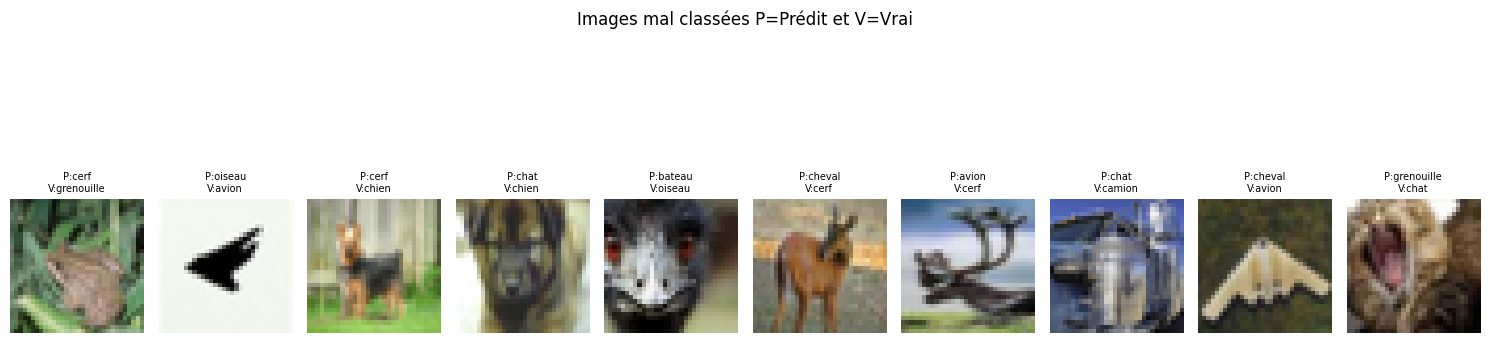

In [21]:
classes = ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 
           'chien', 'grenouille', 'cheval', 'bateau', 'camion']

fig, axes = plt.subplots(1, 10, figsize=(15, 5))

for idx, ax in zip(errors[:10], axes.flat):
    ax.imshow(X_test[idx])
    ax.set_title(f"P:{classes[y_pred[idx]]}\nV:{classes[y_test[idx]]}", 
                 fontsize=7)
    ax.axis('off')

plt.suptitle("Images mal classées P=Prédit et V=Vrai")
plt.tight_layout()
plt.show()

#### Pourcentage d'erreurs par classe


In [22]:
for i, classe in enumerate(classes):
    idx_classe = np.where(y_test == i)[0]
    erreurs_classe = [j for j in idx_classe if y_pred[j] != y_test[j]]
    print(f"{classe:12} : {len(erreurs_classe)} erreurs / {len(idx_classe)} ({len(erreurs_classe)/len(idx_classe)*100:.1f}%)")

avion        : 217 erreurs / 1000 (21.7%)
automobile   : 123 erreurs / 1000 (12.3%)
oiseau       : 369 erreurs / 1000 (36.9%)
chat         : 429 erreurs / 1000 (42.9%)
cerf         : 285 erreurs / 1000 (28.5%)
chien        : 405 erreurs / 1000 (40.5%)
grenouille   : 143 erreurs / 1000 (14.3%)
cheval       : 208 erreurs / 1000 (20.8%)
bateau       : 129 erreurs / 1000 (12.9%)
camion       : 134 erreurs / 1000 (13.4%)


# Bonus : Faire une analyse des confusions entre chat et chien.

### Obtenir les prédictions

In [23]:
y_pred = meilleur_model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### Matrice de confusion

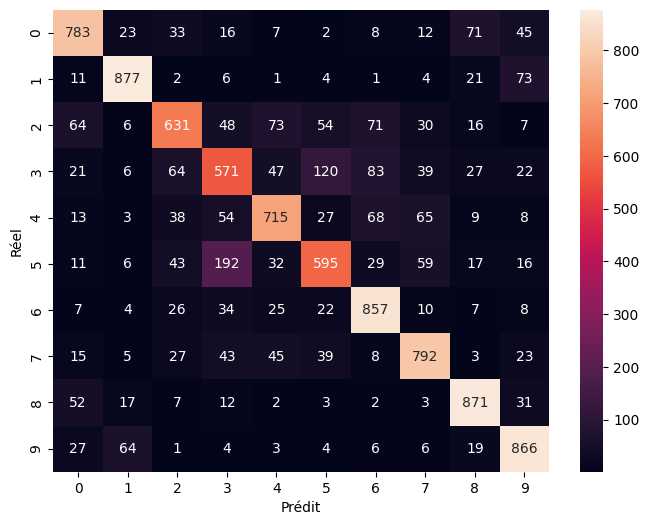

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

#### On voit qu'a part la diagonnale de bonne réponse la valeurs sur laquel le modèle se trompe le plus sont les (3,5) ou bien (5,3), les 3 = chats et les 5 = chiens

### Isoler chat et chien

In [25]:
import numpy as np
y_test = y_test.flatten() # Applatir le y test 
chat_categ = 3
chien_categ = 5

# indices des chats mal classés en chiens
cat_as_dog = np.where((y_test == chat_categ) & (y_pred_classes == chien_categ))[0]

# indices des chiens mal classés en chats
dog_as_cat = np.where((y_test == chien_categ) & (y_pred_classes == chat_categ))[0]

### 10 exemples d'erreurs entre les chats et les chiens

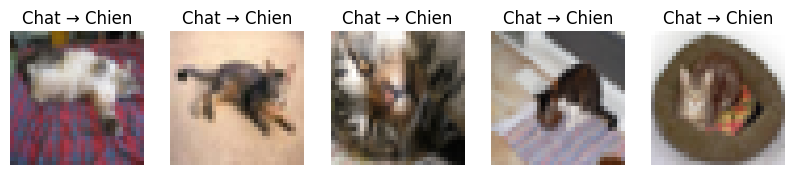

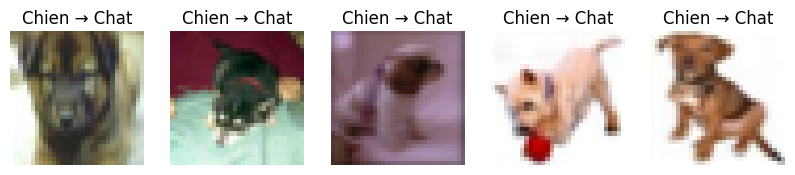

In [26]:
def show_images(indices, title):
    plt.figure(figsize=(10,4))
    for i, idx in enumerate(indices[:5]):
        plt.subplot(1,5,i+1)
        plt.imshow(X_test[idx])
        plt.title(title)
        plt.axis("off")
    plt.show()

show_images(cat_as_dog, "Chat → Chien")
show_images(dog_as_cat, "Chien → Chat")